In [4]:
import pandas as pd
df = pd.read_csv('Downloads/matches.csv')
df['city'] = df['city'].fillna('Unknown')
df.dropna(subset=['winner'], inplace=True)

print(df['toss_winner'].head())
print(df['winner'].head())

0    Royal Challengers Bangalore
1            Chennai Super Kings
2               Rajasthan Royals
3                 Mumbai Indians
4                Deccan Chargers
Name: toss_winner, dtype: str
0          Kolkata Knight Riders
1            Chennai Super Kings
2               Delhi Daredevils
3    Royal Challengers Bangalore
4          Kolkata Knight Riders
Name: winner, dtype: str


In [11]:
df.dtypes

id                      int64
season                    str
city                      str
date                      str
match_type                str
player_of_match           str
venue                     str
team1                     str
team2                     str
toss_winner               str
toss_decision             str
winner                    str
result                    str
result_margin         float64
target_runs           float64
target_overs          float64
super_over                str
method                    str
umpire1                   str
umpire2                   str
toss_win_match_win       bool
dtype: object

In [5]:
df['toss_win_match_win'] = df['toss_winner'] == df['winner']
df['toss_win_match_win'].value_counts()

toss_win_match_win
True     554
False    536
Name: count, dtype: int64

In [6]:
df['toss_win_match_win'].value_counts(normalize=True) * 100

toss_win_match_win
True     50.825688
False    49.174312
Name: proportion, dtype: float64

In [7]:
df.groupby('toss_decision')['toss_win_match_win'].mean() * 100

toss_decision
bat      45.384615
field    53.857143
Name: toss_win_match_win, dtype: float64

In [13]:
df['toss_decision'].value_counts()

toss_decision
field    700
bat      390
Name: count, dtype: int64

In [17]:
df.groupby('city')['id'].count().sort_values(ascending=False)

city
Mumbai            173
Kolkata            93
Delhi              89
Chennai            85
Hyderabad          77
Bangalore          63
Chandigarh         61
Jaipur             57
Unknown            51
Pune               51
Abu Dhabi          37
Ahmedabad          36
Bengaluru          28
Visakhapatnam      15
Durban             15
Dubai              13
Lucknow            13
Dharamsala         13
Centurion          12
Sharjah            10
Rajkot             10
Indore              9
Navi Mumbai         9
Johannesburg        8
Cape Town           7
Ranchi              7
Port Elizabeth      7
Cuttack             7
Raipur              6
Mohali              5
Kochi               5
Kanpur              4
East London         3
Nagpur              3
Guwahati            3
Kimberley           3
Bloemfontein        2
Name: id, dtype: int64

In [20]:
df.groupby('season')['id'].count().sort_values(ascending=False)

season
2013       76
2022       74
2012       74
2023       73
2011       72
2024       71
2020/21    60
2016       60
2009/10    60
2014       60
2021       60
2018       60
2019       59
2017       59
2007/08    58
2015       57
2009       57
Name: id, dtype: int64

In [21]:
import matplotlib.pyplot as plt

In [26]:
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Deccan Chargers': 'Deccan Chargers'
}

df['winner'] = df['winner'].replace(team_name_map)
df['team1'] = df['team1'].replace(team_name_map)
df['team2'] = df['team2'].replace(team_name_map)

In [27]:
top_teams = df.groupby('winner')['id'].count().sort_values(ascending=False)

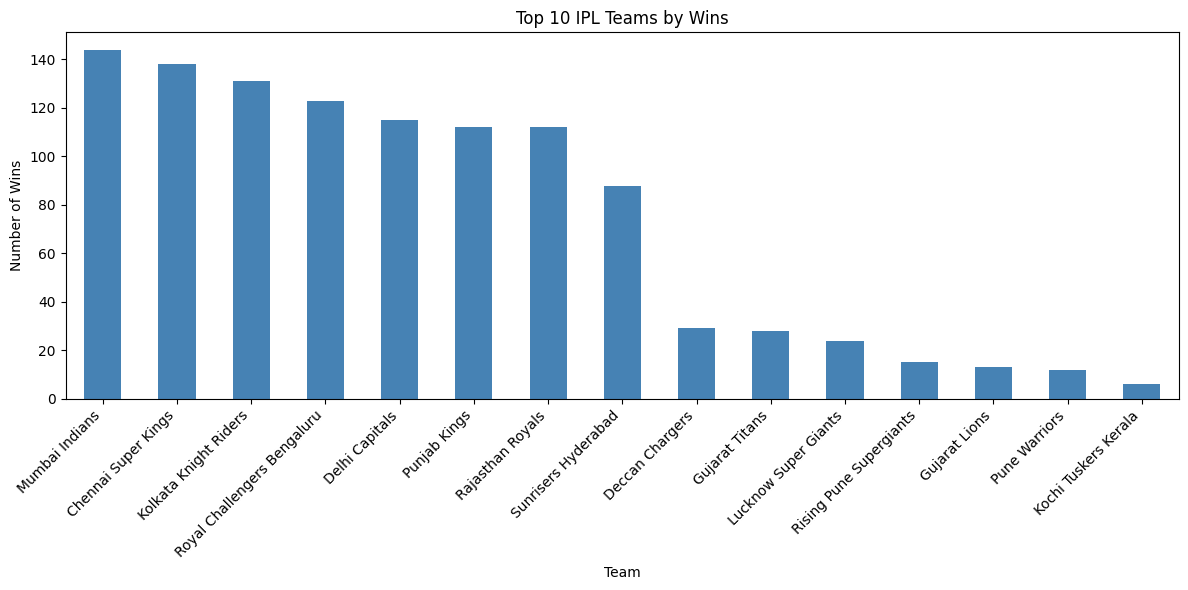

In [28]:
top_teams.plot(kind='bar' ,figsize=(12,6) , color='steelblue')
plt.title('Top 10 IPL Teams by Wins')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

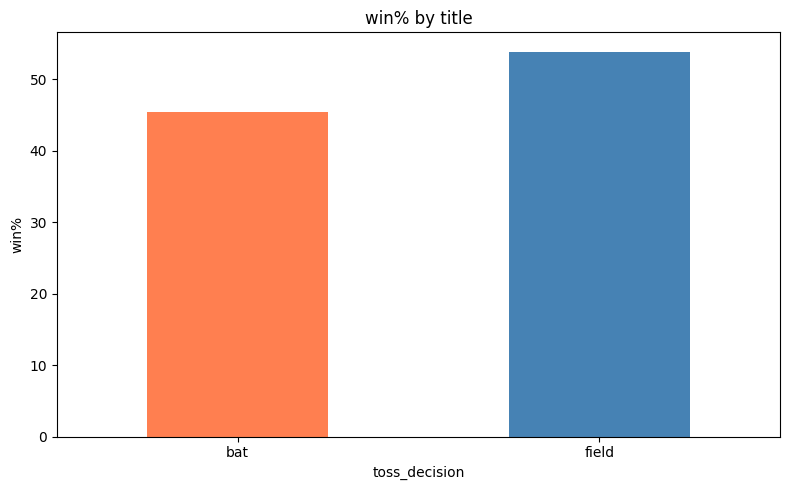

In [43]:
#toss decision
toss_impact = df.groupby('toss_decision')['toss_win_match_win'].mean()*100
toss_impact.plot(kind='bar' , figsize=(8,5) , color=['coral' , 'steelblue'])
plt.title('win% by title')
plt.xlabel('toss_decision')
plt.ylabel('win%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

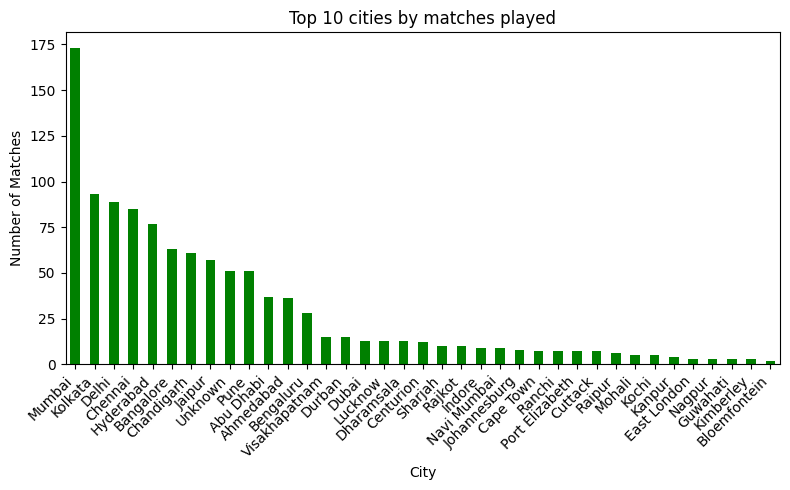

In [49]:
#matches per city
top_cities=df.groupby('city')['id'].count().sort_values(ascending= False)
top_cities.plot(kind='bar' , figsize=(8,5) , color = 'green')
plt.title('Top 10 cities by matches played')
plt.xlabel('City')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45 , ha='right')
plt.tight_layout()
plt.show()           